# Segmentasi Perilaku Nasabah Kartu Kredit dengan K-Means Clustering
### Mitigasi Kerentanan Finansial pada Sindrom Minimum Payment dan Ketergantungan Tarik Tunai

**Dataset:** CC_GENERAL (8.950 nasabah, 17 fitur numerik) — sumber: [Kaggle - arjunbhasin2013/ccdata](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

Notebook ini mengikuti struktur metodologi **CRISP-DM** sesuai laporan UAS:
1. Data Quality Assessment
2. Exploratory Data Analysis (EDA)
3. Pra-pemrosesan & Rekayasa Fitur
4. Pemodelan & Evaluasi K-Means
5. Profiling Klaster & Analisis Dampak Bisnis


## 0. Setup & Load Dataset

Memuat seluruh library yang dibutuhkan di satu tempat, lalu membaca dataset `CC_GENERAL.csv`. Path disesuaikan untuk Google Colab — jika file diunggah langsung ke sesi Colab (bukan dari Drive), gunakan `/content/CC_GENERAL.csv`.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, pairwise_distances_argmin_min
from sklearn import set_config

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

path_file = '/content/sample_data/CC GENERAL.csv'

df = pd.read_csv(path_file)
df.columns = df.columns.str.strip()

print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()


Dimensi dataset: 8950 baris, 18 kolom


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 1. Pemeriksaan Kualitas Data (Data Quality Assessment)

Mengevaluasi kondisi awal dataset melalui identifikasi nilai kosong (*missing values*) dan duplikasi data guna mencegah bias pada pemodelan. Selain itu, sel ini menghitung persentase pencilan (*outlier*) menggunakan metode IQR sebagai justifikasi empiris mengenai perlunya transformasi logaritmik sebelum data diproses oleh algoritma K-Means.

*Acuan laporan: Bab II.2.2 — Kualitas Data.*

In [4]:
# 1. Cek Missing Values (Nilai Hilang)
print("--- Analisis Missing Values ---")
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
df_missing = pd.DataFrame({'Jumlah Missing': missing_data, 'Persentase (%)': missing_percent})
print(df_missing[df_missing['Jumlah Missing'] > 0])

# 2. Cek Duplikasi (Baris Ganda & CUST_ID)
print("\n--- Analisis Duplikasi ---")
duplicate_rows = df.duplicated().sum()
duplicate_ids = df['CUST_ID'].duplicated().sum()
print(f"Jumlah baris duplikat   : {duplicate_rows}")
print(f"Jumlah CUST_ID duplikat : {duplicate_ids}")

# 3. Deteksi Outlier dengan Metode IQR
def hitung_outlier_iqr(data):
    outlier_report = []
    cols = data.select_dtypes(include=['float64', 'int64']).columns

    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        batas_bawah = Q1 - 1.5 * IQR
        batas_atas = Q3 + 1.5 * IQR

        jumlah_outlier = ((data[col] < batas_bawah) | (data[col] > batas_atas)).sum()
        persentase = (jumlah_outlier / len(data)) * 100

        outlier_report.append({
            'Fitur': col,
            'Jumlah Outlier': jumlah_outlier,
            'Persentase (%)': round(persentase, 1)
        })

    return pd.DataFrame(outlier_report).sort_values(by='Persentase (%)', ascending=False).reset_index(drop=True)

print("\n--- Deteksi Outlier Berdasarkan Metode IQR ---")
outlier_table = hitung_outlier_iqr(df)
print(outlier_table)


--- Analisis Missing Values ---
                  Jumlah Missing  Persentase (%)
CREDIT_LIMIT                   1        0.011173
MINIMUM_PAYMENTS             313        3.497207

--- Analisis Duplikasi ---
Jumlah baris duplikat   : 0
Jumlah CUST_ID duplikat : 0

--- Deteksi Outlier Berdasarkan Metode IQR ---
                               Fitur  Jumlah Outlier  Persentase (%)
0                  BALANCE_FREQUENCY            1493            16.7
1                   PRC_FULL_PAYMENT            1474            16.5
2                             TENURE            1366            15.3
3                       CASH_ADVANCE            1030            11.5
4                   ONEOFF_PURCHASES            1013            11.3
5             INSTALLMENTS_PURCHASES             867             9.7
6                   MINIMUM_PAYMENTS             841             9.4
7                           PAYMENTS             808             9.0
8                          PURCHASES             808             9.0

## 2. Exploratory Data Analysis (EDA)

### 2.1 Distribusi Fitur dan Temuan Skewness

Menghitung nilai kemiringan (*skewness*) untuk membuktikan secara kuantitatif kecondongan distribusi (*right-skewed*) pada fitur transaksional utama, lalu memvisualisasikannya melalui histogram dan kurva densitas (KDE).

*Acuan laporan: Bab II.2.3.2 — Distribusi Fitur dan Temuan Skewness (Gambar 2.3).*

--- Skewness Seluruh Fitur Numerik (Urutan Tertinggi) ---
                    Fitur   Skewness
0        MINIMUM_PAYMENTS  13.622797
1        ONEOFF_PURCHASES  10.045083
2               PURCHASES   8.144269
3  INSTALLMENTS_PURCHASES   7.299120
4                PAYMENTS   5.907620
5        CASH_ADVANCE_TRX   5.721298
6            CASH_ADVANCE   5.166609
7           PURCHASES_TRX   4.630655
8                 BALANCE   2.393386
9        PRC_FULL_PAYMENT   1.942820


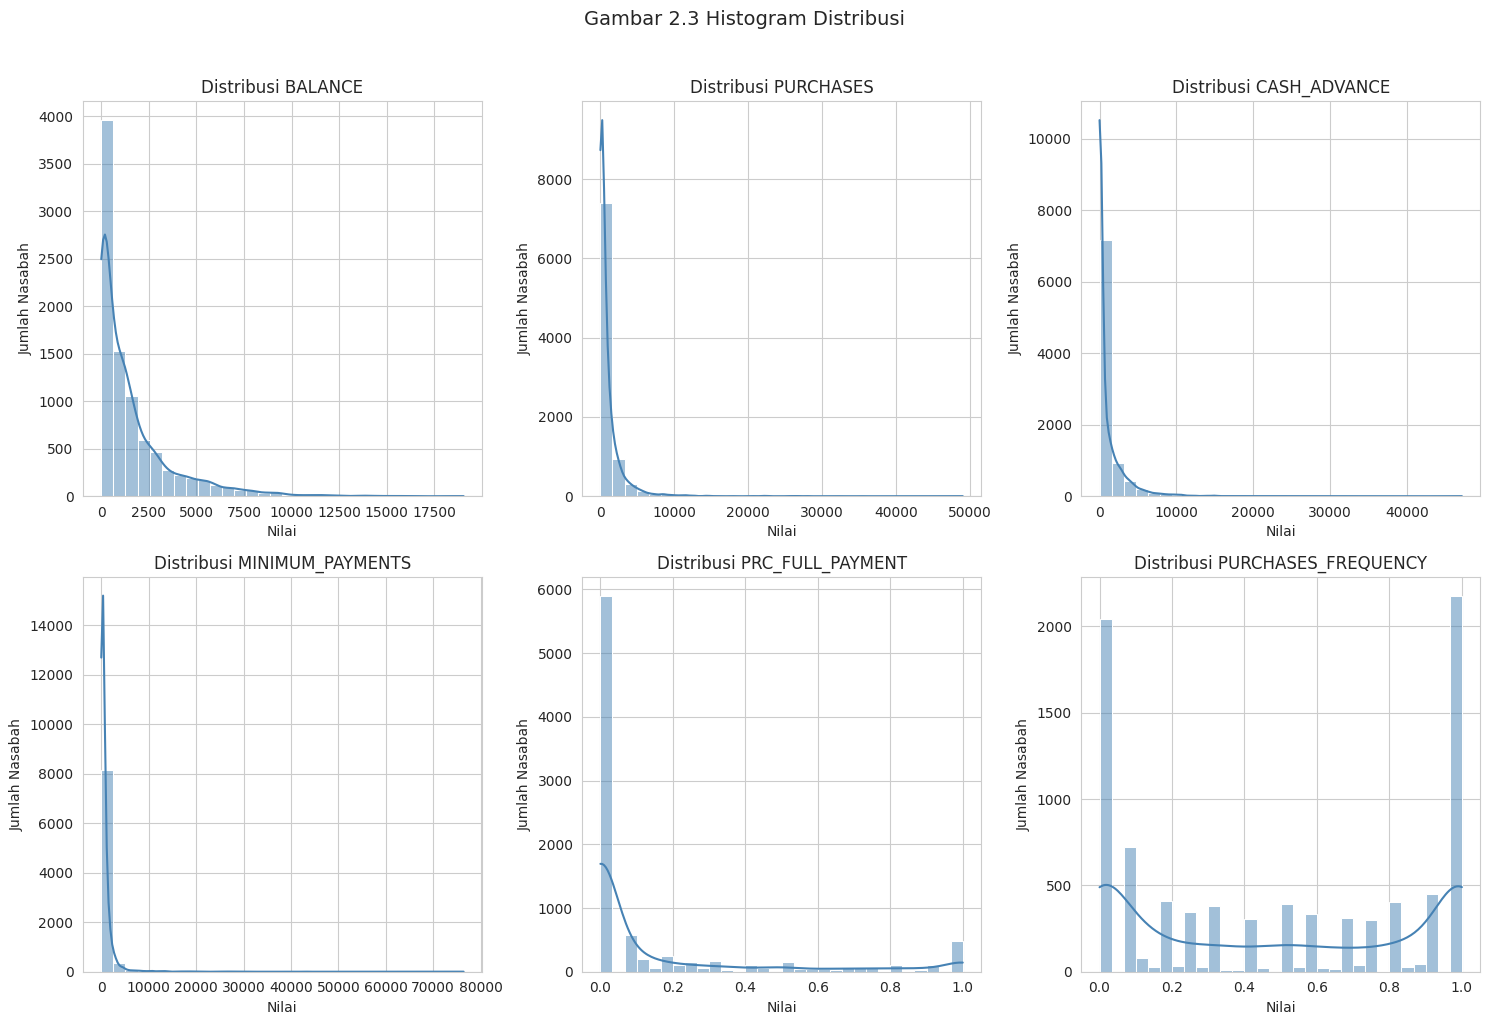

In [5]:
# Hitung skewness seluruh fitur numerik, urutkan dari yang paling miring
skew_table = df.drop(columns=['CUST_ID']).skew().sort_values(ascending=False).reset_index()
skew_table.columns = ['Fitur', 'Skewness']
print("--- Skewness Seluruh Fitur Numerik (Urutan Tertinggi) ---")
print(skew_table.head(10))

# Visualisasi histogram + KDE untuk fitur transaksional utama
cols_to_plot = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE',
    'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Jumlah Nasabah')

plt.suptitle('Gambar 2.3 Histogram Distribusi', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### 2.2 Analisis Zero-Inflation (Penumpukan Nilai Nol)

Menghitung dan memvisualisasikan persentase nilai nol pada setiap fitur menggunakan diagram batang. Visualisasi ini memperkuat argumen perlunya rekayasa fitur indikator biner pada tahap selanjutnya.

*Acuan laporan: Bab II.2.3.3 — Analisis Zero-Inflation (Gambar 2.4).*

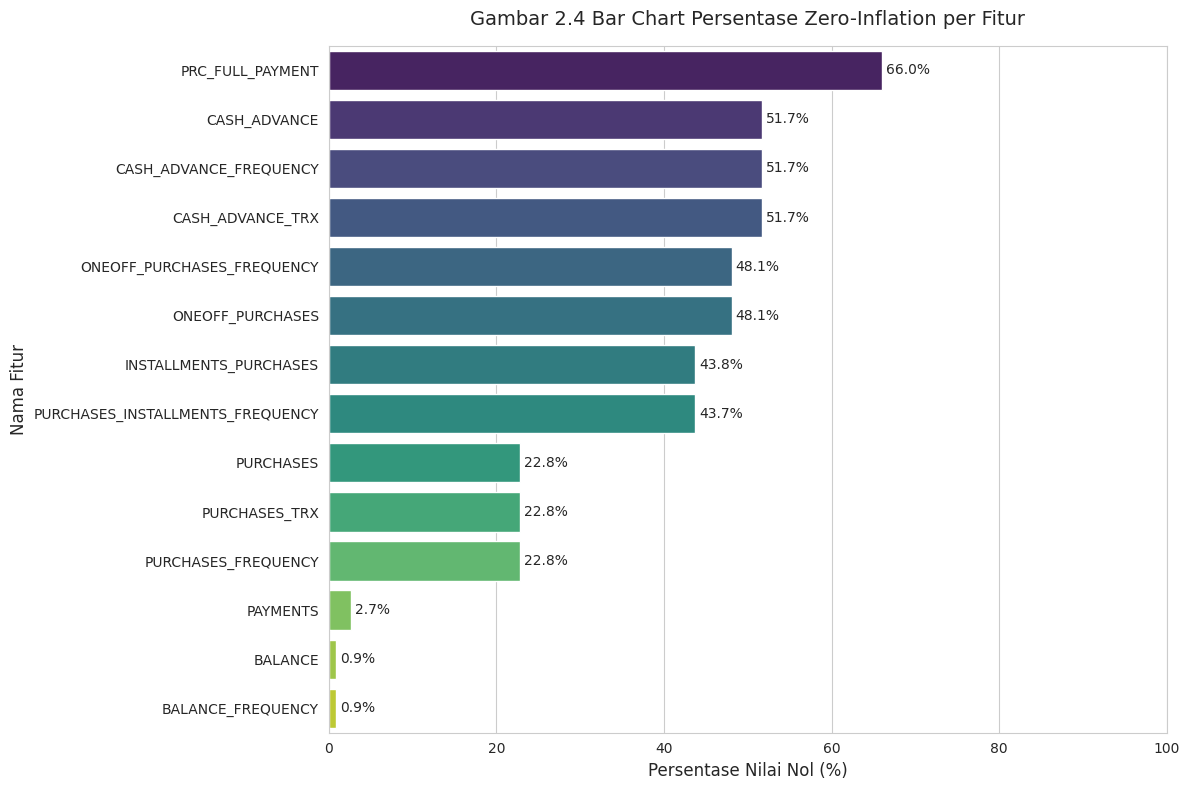

--- Analisis Silang: Profil 'Gali Lubang Tutup Lubang' ---
Nasabah dengan PURCHASES = 0 namun CASH_ADVANCE > 0: 2043 orang (22.8% dari total populasi)


In [6]:
# Hitung persentase nilai 0 di tiap kolom
zero_counts = (df.drop(columns=['CUST_ID']) == 0).sum()
zero_percent = (zero_counts / len(df)) * 100
zero_percent = zero_percent[zero_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=zero_percent.values, y=zero_percent.index, hue=zero_percent.index,
            palette="viridis", legend=False)

for index, value in enumerate(zero_percent.values):
    plt.text(value + 0.5, index, f'{value:.1f}%', va='center', fontsize=10)

plt.title('Gambar 2.4 Bar Chart Persentase Zero-Inflation per Fitur', fontsize=14, pad=15)
plt.xlabel('Persentase Nilai Nol (%)', fontsize=12)
plt.ylabel('Nama Fitur', fontsize=12)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

# Analisis silang: nasabah yang tidak pernah belanja ritel namun aktif tarik tunai
mask_gali_lubang = (df['PURCHASES'] == 0) & (df['CASH_ADVANCE'] > 0)
jumlah_gali_lubang = mask_gali_lubang.sum()
persen_gali_lubang = mask_gali_lubang.mean() * 100

print("--- Analisis Silang: Profil 'Gali Lubang Tutup Lubang' ---")
print(f"Nasabah dengan PURCHASES = 0 namun CASH_ADVANCE > 0: "
      f"{jumlah_gali_lubang} orang ({persen_gali_lubang:.1f}% dari total populasi)")


### 2.3 Analisis Multikolinearitas (Heatmap Korelasi Pearson)

Menghitung matriks korelasi Pearson antar fitur numerik dan memvisualisasikannya dalam bentuk heatmap untuk mengidentifikasi pasangan fitur dengan korelasi ekstrem yang berpotensi mendistorsi perhitungan jarak Euclidean pada K-Means.

*Acuan laporan: Bab II.2.3.4 — Analisis Multikolinearitas (Gambar 2.5).*

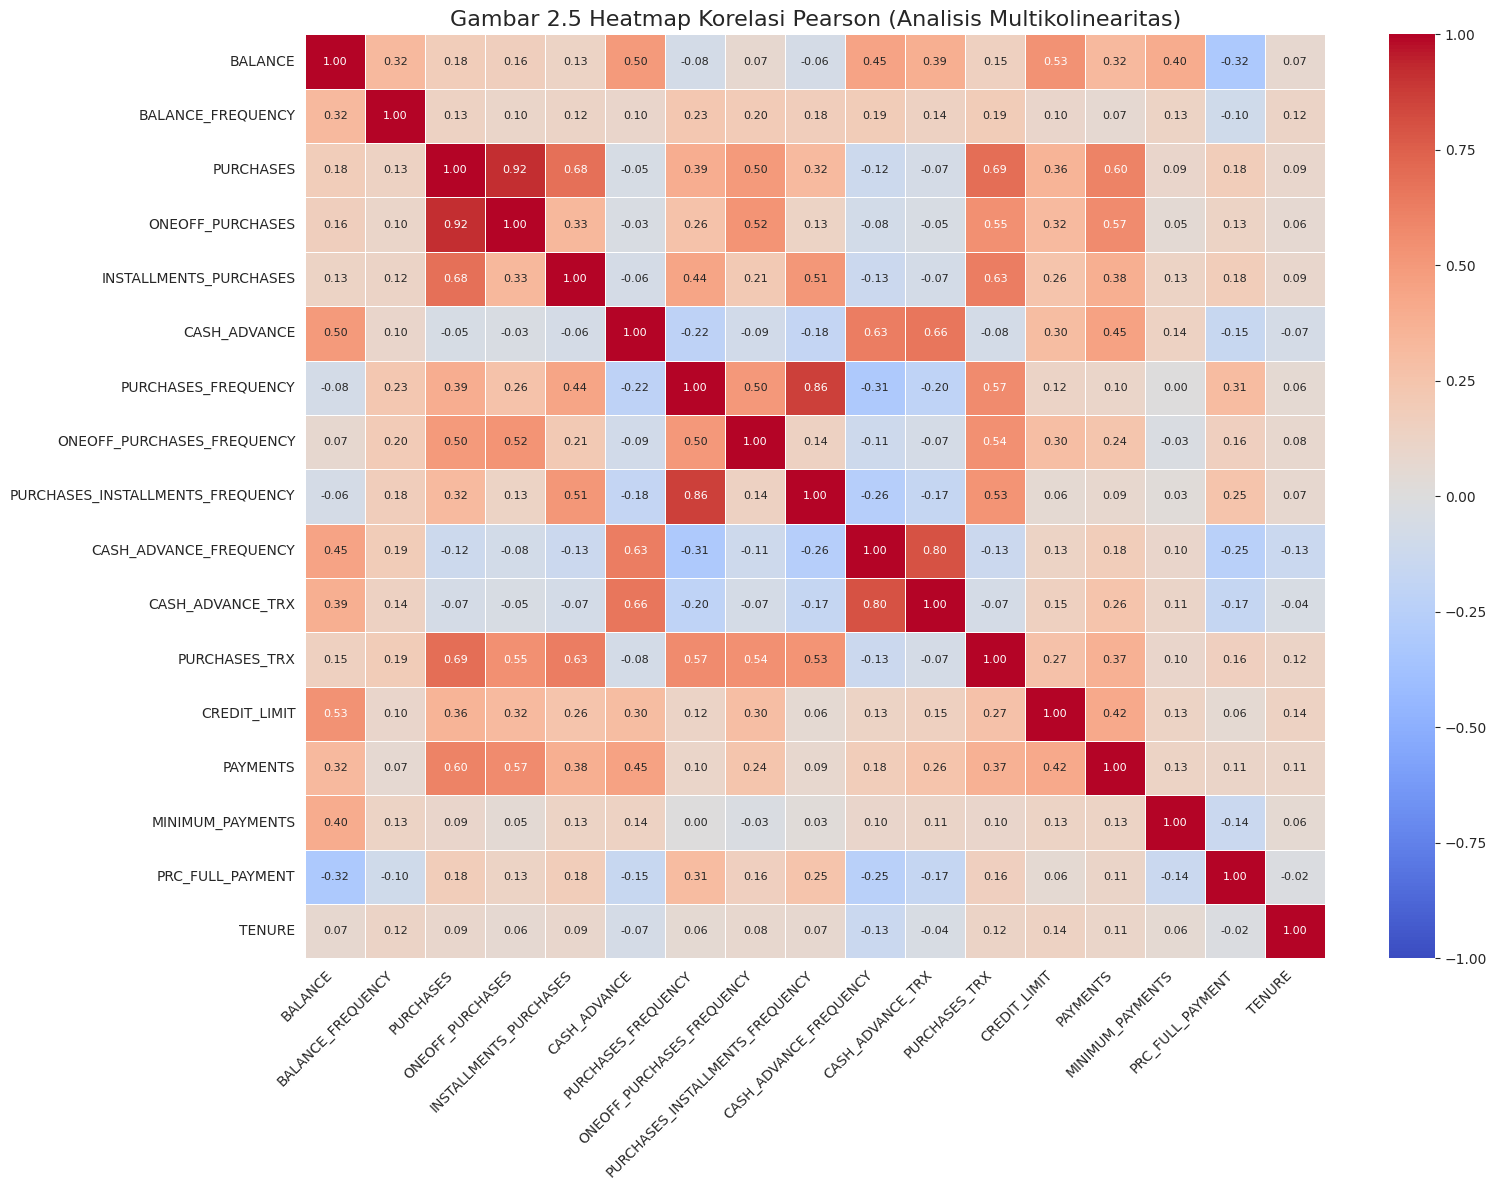

--- Lima Pasangan Fitur dengan Korelasi Tertinggi ---
ONEOFF_PURCHASES                    vs PURCHASES                           : 0.917
PURCHASES_FREQUENCY                 vs PURCHASES_INSTALLMENTS_FREQUENCY    : 0.863
CASH_ADVANCE_FREQUENCY              vs CASH_ADVANCE_TRX                    : 0.800
PURCHASES                           vs PURCHASES_TRX                       : 0.690
INSTALLMENTS_PURCHASES              vs PURCHASES                           : 0.680


In [7]:
df_corr = df.drop(columns=['CUST_ID'])
corr_matrix = df_corr.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={"size": 8})
plt.title('Gambar 2.5 Heatmap Korelasi Pearson (Analisis Multikolinearitas)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Pasangan fitur dengan korelasi tertinggi (selain diagonal)
corr_pairs = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).unstack().dropna()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]
top_corr = corr_pairs.sort_values(ascending=False).head(5)

print("--- Lima Pasangan Fitur dengan Korelasi Tertinggi ---")
for (f1, f2), val in top_corr.items():
    print(f"{f1:35s} vs {f2:35s} : {val:.3f}")


## 3. Pra-pemrosesan Data dan Rekayasa Fitur

Merangkum seluruh tahapan penyiapan data sebelum masuk ke pemodelan:
1. **Pencegahan data leakage**: split 80:20 (train/holdout) dilakukan **sebelum** fitting scaler/PCA.
2. **Imputasi** nilai kosong dengan median (`MINIMUM_PAYMENTS`, `CREDIT_LIMIT`).
3. **Rekayasa fitur**: indikator biner zero-inflation + rasio (`UTILIZATION_RATIO`, `CASH_RELIANCE_RATIO`).
4. **Transformasi logaritmik** (`log1p`) untuk fitur yang sangat skewed.
5. **RobustScaler** + **PCA (95% variansi)** untuk menangani outlier dan multikolinearitas secara bersamaan.

*Acuan laporan: Bab IV.4.1 – 4.4.*

In [8]:
# 1. Buang kolom ID, salin dataframe kerja
df_feature = df.drop(columns=['CUST_ID']).copy()

# 2. Imputasi nilai kosong dengan median (distribusi sangat skewed -> median lebih representatif)
df_feature['MINIMUM_PAYMENTS'] = df_feature['MINIMUM_PAYMENTS'].fillna(df_feature['MINIMUM_PAYMENTS'].median())
df_feature['CREDIT_LIMIT'] = df_feature['CREDIT_LIMIT'].fillna(df_feature['CREDIT_LIMIT'].median())

print("--- Validasi Pasca-Imputasi ---")
print(df_feature[['MINIMUM_PAYMENTS', 'CREDIT_LIMIT']].isnull().sum())

# 3. Rekayasa fitur baru
df_feature['IS_ZERO_FULL_PAYMENT'] = (df_feature['PRC_FULL_PAYMENT'] == 0).astype(int)
df_feature['IS_ZERO_CASH_ADVANCE'] = (df_feature['CASH_ADVANCE'] == 0).astype(int)
df_feature['UTILIZATION_RATIO'] = df_feature['BALANCE'] / (df_feature['CREDIT_LIMIT'] + 1)
df_feature['CASH_RELIANCE_RATIO'] = df_feature['CASH_ADVANCE'] / (df_feature['PURCHASES'] + 1)

kolom_biner = ['IS_ZERO_FULL_PAYMENT', 'IS_ZERO_CASH_ADVANCE']
kolom_numerik = [col for col in df_feature.columns if col not in kolom_biner]
kolom_skewed = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT',
    'PAYMENTS', 'MINIMUM_PAYMENTS', 'UTILIZATION_RATIO', 'CASH_RELIANCE_RATIO'
]

print(f"\nTotal fitur setelah rekayasa: {df_feature.shape[1]} kolom")
df_feature.head()


--- Validasi Pasca-Imputasi ---
MINIMUM_PAYMENTS    0
CREDIT_LIMIT        0
dtype: int64

Total fitur setelah rekayasa: 21 kolom


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,IS_ZERO_FULL_PAYMENT,IS_ZERO_CASH_ADVANCE,UTILIZATION_RATIO,CASH_RELIANCE_RATIO
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1,1,0.040860,0.000000
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0,0,0.457430,6442.945483
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1,1,0.332642,0.000000
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,1,0,0.222193,0.137192
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1,1,0.680861,0.000000


In [9]:
# 4. PENCEGAHAN DATA LEAKAGE: split 80:20 SEBELUM scaling/PCA dilakukan
df_train, df_holdout = train_test_split(df_feature, test_size=0.2, random_state=42)

print(f"Jumlah data latih   : {len(df_train)} baris ({len(df_train)/len(df_feature)*100:.0f}%)")
print(f"Jumlah data holdout : {len(df_holdout)} baris ({len(df_holdout)/len(df_feature)*100:.0f}%)")


Jumlah data latih   : 7160 baris (80%)
Jumlah data holdout : 1790 baris (20%)


### 3.1 Eksperimen Pra-pemrosesan: Transformasi Log1p vs Clipping (Winsorizing)

Membandingkan efek transformasi logaritmik (`log1p`) dan *clipping* persentil ke-95 terhadap distribusi fitur yang sangat skewed. Sesuai laporan, *clipping* terbukti merapikan rentang data secara visual namun **tidak digunakan pada model utama** karena berisiko menghilangkan informasi perilaku nasabah ekstrem yang valid secara bisnis — model utama dibangun di atas `log1p` + `RobustScaler`.

*Acuan laporan: Bab IV.4.3 (Gambar 4.1) dan Bab IV.4.5 (Gambar 4.3).*

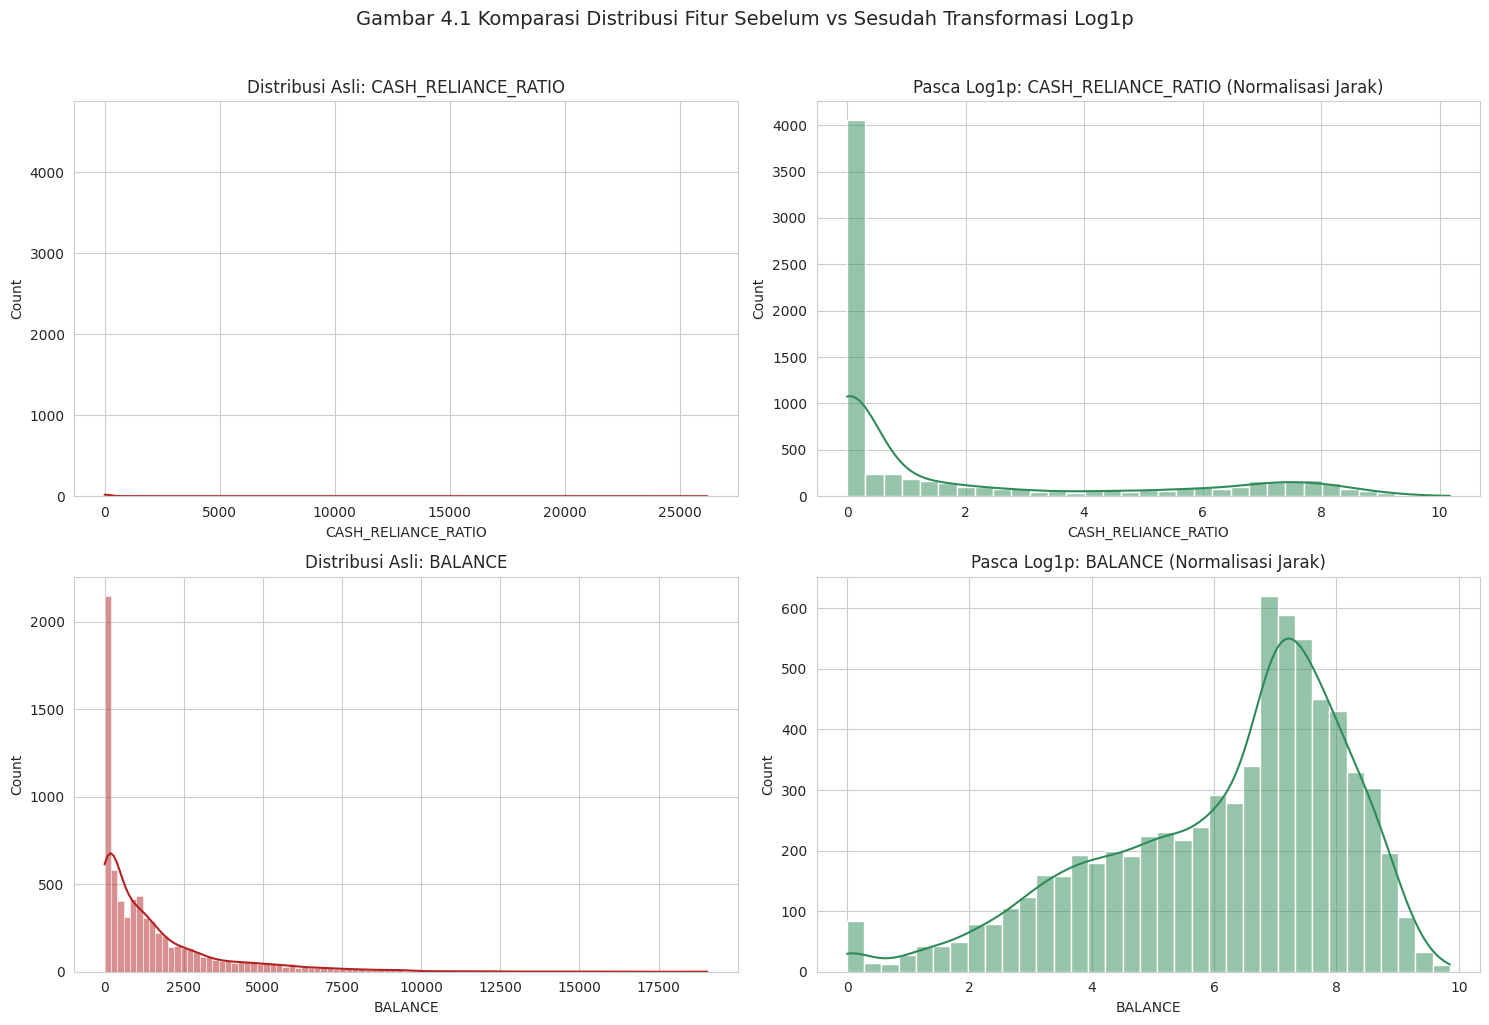

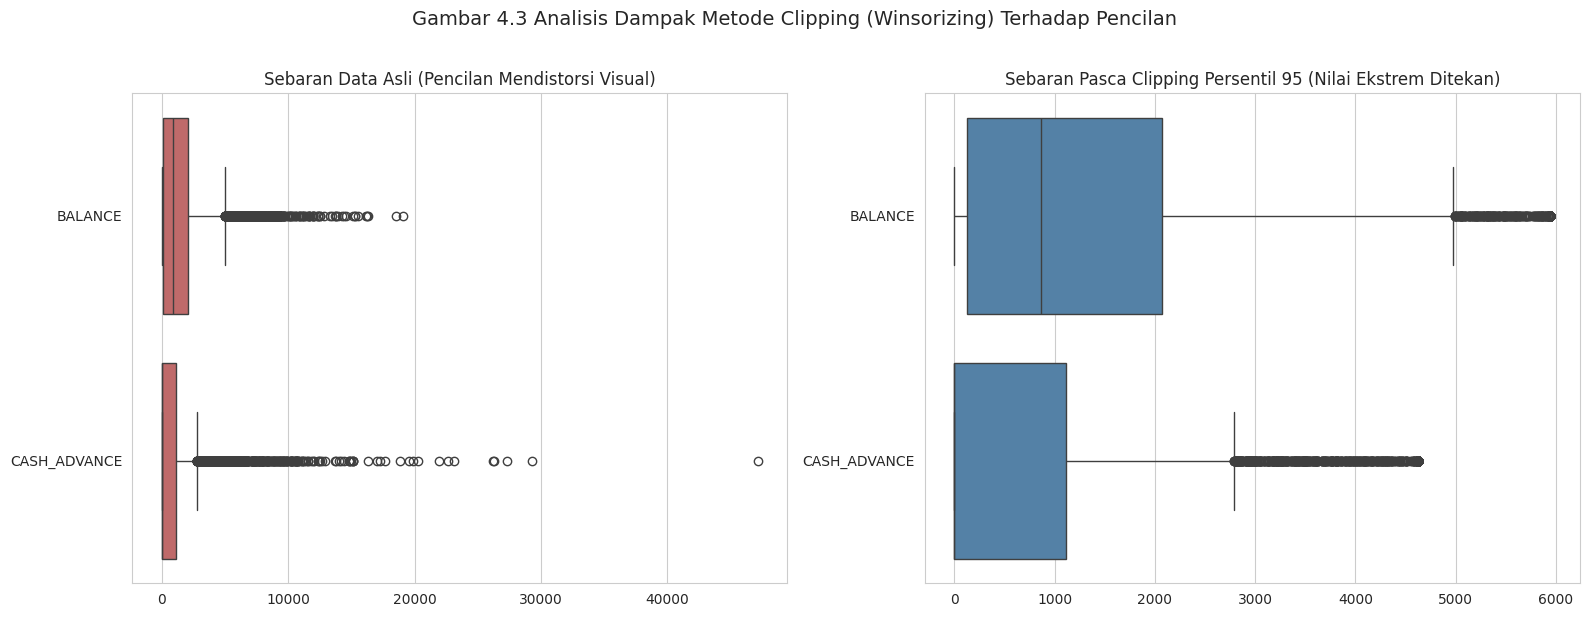

Keputusan metodologis: Clipping HANYA dipakai untuk eksperimen visual di atas.
Model utama menggunakan log1p + RobustScaler agar nilai asli nasabah ekstrem tetap dipertahankan.


In [10]:
# --- Transformasi Log1p (jalur utama) ---
df_train_log = df_train.copy()
df_holdout_log = df_holdout.copy()

for col in kolom_skewed:
    df_train_log[col] = np.log1p(df_train_log[col])
    df_holdout_log[col] = np.log1p(df_holdout_log[col])

# --- Eksperimen Clipping persentil ke-95 (hanya untuk perbandingan visual) ---
df_train_clipped = df_train.copy()
for col in kolom_skewed:
    batas_atas = df_train_clipped[col].quantile(0.95)
    df_train_clipped[col] = np.clip(df_train_clipped[col], a_min=None, a_max=batas_atas)

# Visualisasi komparasi distribusi SEBELUM vs SESUDAH log1p
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Gambar 4.1 Komparasi Distribusi Fitur Sebelum vs Sesudah Transformasi Log1p', fontsize=14, y=1.02)

sns.histplot(df_train['CASH_RELIANCE_RATIO'], kde=True, ax=axes[0, 0], color='firebrick')
axes[0, 0].set_title('Distribusi Asli: CASH_RELIANCE_RATIO')

sns.histplot(df_train_log['CASH_RELIANCE_RATIO'], kde=True, ax=axes[0, 1], color='seagreen')
axes[0, 1].set_title('Pasca Log1p: CASH_RELIANCE_RATIO (Normalisasi Jarak)')

sns.histplot(df_train['BALANCE'], kde=True, ax=axes[1, 0], color='firebrick')
axes[1, 0].set_title('Distribusi Asli: BALANCE')

sns.histplot(df_train_log['BALANCE'], kde=True, ax=axes[1, 1], color='seagreen')
axes[1, 1].set_title('Pasca Log1p: BALANCE (Normalisasi Jarak)')

plt.tight_layout()
plt.show()

# Visualisasi komparasi dampak clipping (Winsorizing) terhadap pencilan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Gambar 4.3 Analisis Dampak Metode Clipping (Winsorizing) Terhadap Pencilan', fontsize=14, y=1.02)

sns.boxplot(data=df_train[['BALANCE', 'CASH_ADVANCE']], orient='h', ax=axes[0], color='indianred')
axes[0].set_title('Sebaran Data Asli (Pencilan Mendistorsi Visual)')

sns.boxplot(data=df_train_clipped[['BALANCE', 'CASH_ADVANCE']], orient='h', ax=axes[1], color='steelblue')
axes[1].set_title('Sebaran Pasca Clipping Persentil 95 (Nilai Ekstrem Ditekan)')

plt.tight_layout()
plt.show()

print("Keputusan metodologis: Clipping HANYA dipakai untuk eksperimen visual di atas.")
print("Model utama menggunakan log1p + RobustScaler agar nilai asli nasabah ekstrem tetap dipertahankan.")


### 3.2 Desain Pipeline Modular (`sklearn.Pipeline`)

Pipeline final menggabungkan **tiga tahapan** secara berurutan — `Log_Transform` (transformasi `log1p` **selektif**, hanya pada kolom yang teridentifikasi sangat skewed di Bab 2), `Robust_Scaler` (`RobustScaler`), dan `PCA_Reduction` (`PCA(n_components=0.95)`) — sehingga proses transformasi data baru (holdout/data produksi) konsisten dan bebas dari kebocoran data. Pipeline ini di-*fit* hanya pada data latih, lalu dipakai untuk men-*transform* data holdout dan dataset penuh.

Transformasi `log1p` dibungkus sebagai `FunctionTransformer` yang **hanya menyentuh kolom skewed** (`kolom_skewed`), bukan seluruh fitur — fitur rasio/frekuensi yang sudah berskala 0–1 (mis. `PURCHASES_FREQUENCY`, `IS_ZERO_*`) dibiarkan apa adanya, sesuai justifikasi pada Bab IV.4.3.

*Acuan laporan: Bab IV.4.6 (Gambar 4.4).*

In [11]:
# Indeks posisi kolom skewed di dalam kolom_numerik -> dipakai FunctionTransformer selektif
idx_skewed = [kolom_numerik.index(c) for c in kolom_skewed]

def log1p_selektif(X):
    X = np.asarray(X, dtype=float).copy()
    X[:, idx_skewed] = np.log1p(X[:, idx_skewed])
    return X

log_transformer = FunctionTransformer(log1p_selektif, validate=True)

preprocessing_pipeline = Pipeline(steps=[
    ('Log_Transform', log_transformer),
    ('Robust_Scaler', RobustScaler()),
    ('PCA_Reduction', PCA(n_components=0.95, random_state=42))
])

# Fit HANYA pada data latih (mentah) -> log1p selektif jadi bagian resmi pipeline
X_train_pca = pd.DataFrame(preprocessing_pipeline.fit_transform(df_train[kolom_numerik]))
X_holdout_pca = pd.DataFrame(preprocessing_pipeline.transform(df_holdout[kolom_numerik]))

X_transformed = X_train_pca  # alias dipakai pada sel evaluasi K-Means

print(f"Dimensi Data Latih (PCA)   : {X_train_pca.shape}")
print(f"Dimensi Data Holdout (PCA) : {X_holdout_pca.shape}")
print(f"Total komponen PCA yang terbentuk: {X_train_pca.shape[1]}")

# Tampilkan diagram arsitektur pipeline
set_config(display='diagram')
preprocessing_pipeline


Dimensi Data Latih (PCA)   : (7160, 9)
Dimensi Data Holdout (PCA) : (1790, 9)
Total komponen PCA yang terbentuk: 9


Pipeline(steps=[('Log_Transform',
                 FunctionTransformer(func=<function log1p_selektif at 0x7c50458e4cc0>,
                                     validate=True)),
                ('Robust_Scaler', RobustScaler()),
                ('PCA_Reduction', PCA(n_components=0.95, random_state=42))])

### 3.3 Validasi Reduksi Dimensi: Scree Plot PCA

Memvalidasi secara matematis bahwa komponen PCA yang dipilih berhasil mempertahankan minimal 95% variansi informasi data asli.

*Acuan laporan: Bab IV.4.4 (Gambar 4.2).*

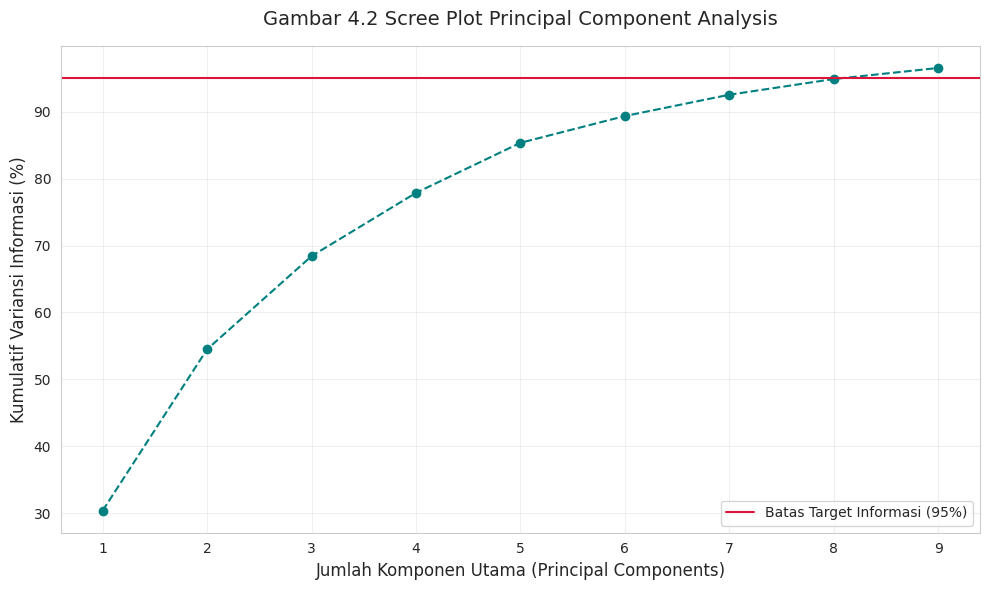

Total variansi dipertahankan oleh 9 komponen: 96.54%


In [12]:
pca_model = preprocessing_pipeline.named_steps['PCA_Reduction']

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca_model.explained_variance_ratio_) + 1),
         np.cumsum(pca_model.explained_variance_ratio_) * 100,
         marker='o', linestyle='--', color='teal')
plt.axhline(y=95, color='crimson', linestyle='-', label='Batas Target Informasi (95%)')
plt.title('Gambar 4.2 Scree Plot Principal Component Analysis', fontsize=14, pad=15)
plt.xlabel('Jumlah Komponen Utama (Principal Components)', fontsize=12)
plt.ylabel('Kumulatif Variansi Informasi (%)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total variansi dipertahankan oleh {pca_model.n_components_} komponen: "
      f"{np.sum(pca_model.explained_variance_ratio_)*100:.2f}%")


## 4. Pemodelan dan Evaluasi

### 4.1 Baseline Model vs Model Utama, Eksperimen Jumlah Klaster (K)

Menjalankan K-Means baseline (data mentah + scaler dasar saja, **tanpa** log1p/PCA) sebagai pembanding objektif terhadap model utama (pipeline lengkap). Selain itu, Agglomerative Clustering disertakan sebagai model pembanding tambahan. Setiap skenario dievaluasi pada rentang K=2 hingga 8 menggunakan Inertia, Silhouette Score, dan Davies-Bouldin Index (DBI).

*Acuan laporan: Bab V.5.1 dan V.5.2.*

In [13]:
# Baseline: scaler dasar saja, TANPA log1p maupun PCA (kondisi operasional paling minimal)
scaler_base = RobustScaler()
X_baseline = pd.DataFrame(scaler_base.fit_transform(df_train[kolom_numerik]), columns=kolom_numerik)

def evaluate_kmeans_range(x_train, k_range=range(2, 9), random_state=42):
    results = []
    models = {}
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=random_state)
        labels = km.fit_predict(x_train)
        results.append({
            'K': k,
            'Inertia': km.inertia_,
            'Silhouette': silhouette_score(x_train, labels),
            'DBI': davies_bouldin_score(x_train, labels)
        })
        models[k] = km
    return pd.DataFrame(results), models

def evaluate_agglomerative_range(x_train, k_range=range(2, 9)):
    results = []
    for k in k_range:
        agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = agg.fit_predict(x_train)
        results.append({
            'K': k,
            'Silhouette': silhouette_score(x_train, labels),
            'DBI': davies_bouldin_score(x_train, labels)
        })
    return pd.DataFrame(results)

df_eval_baseline, _ = evaluate_kmeans_range(X_baseline)
df_eval_main, models_main = evaluate_kmeans_range(X_transformed)
df_eval_agglo = evaluate_agglomerative_range(X_transformed)

print("Evaluasi K-Means (Baseline - data mentah):")
print(df_eval_baseline[['K', 'Silhouette', 'DBI']])
print("\nEvaluasi K-Means (Model Utama - Log1p+RobustScaler+PCA):")
print(df_eval_main[['K', 'Silhouette', 'DBI']])


Evaluasi K-Means (Baseline - data mentah):
   K  Silhouette       DBI
0  2    0.874223  0.490868
1  3    0.853477  0.467258
2  4    0.846207  0.468924
3  5    0.820747  0.496074
4  6    0.804483  0.466908
5  7    0.779127  0.486798
6  8    0.783219  0.476745

Evaluasi K-Means (Model Utama - Log1p+RobustScaler+PCA):
   K  Silhouette       DBI
0  2    0.324725  1.623008
1  3    0.364928  1.139423
2  4    0.303805  1.172476
3  5    0.316406  1.082089
4  6    0.270691  1.227640
5  7    0.273420  1.172796
6  8    0.273093  1.239267


### 4.2 Visualisasi Evaluasi Model dan Penentuan K-Optimal

Memvisualisasikan komparasi tiga metrik evaluasi untuk menentukan K optimal secara objektif (kombinasi DBI ≤ 1.5 dan Silhouette tertinggi), lalu menguji stabilitas model (*robustness test*) dengan membandingkan performa pada data latih vs data holdout.

*Acuan laporan: Bab V.5.2.1 – 5.2.2 dan Bab V.5.4 (Gambar 5.1, Gambar 5.2).*

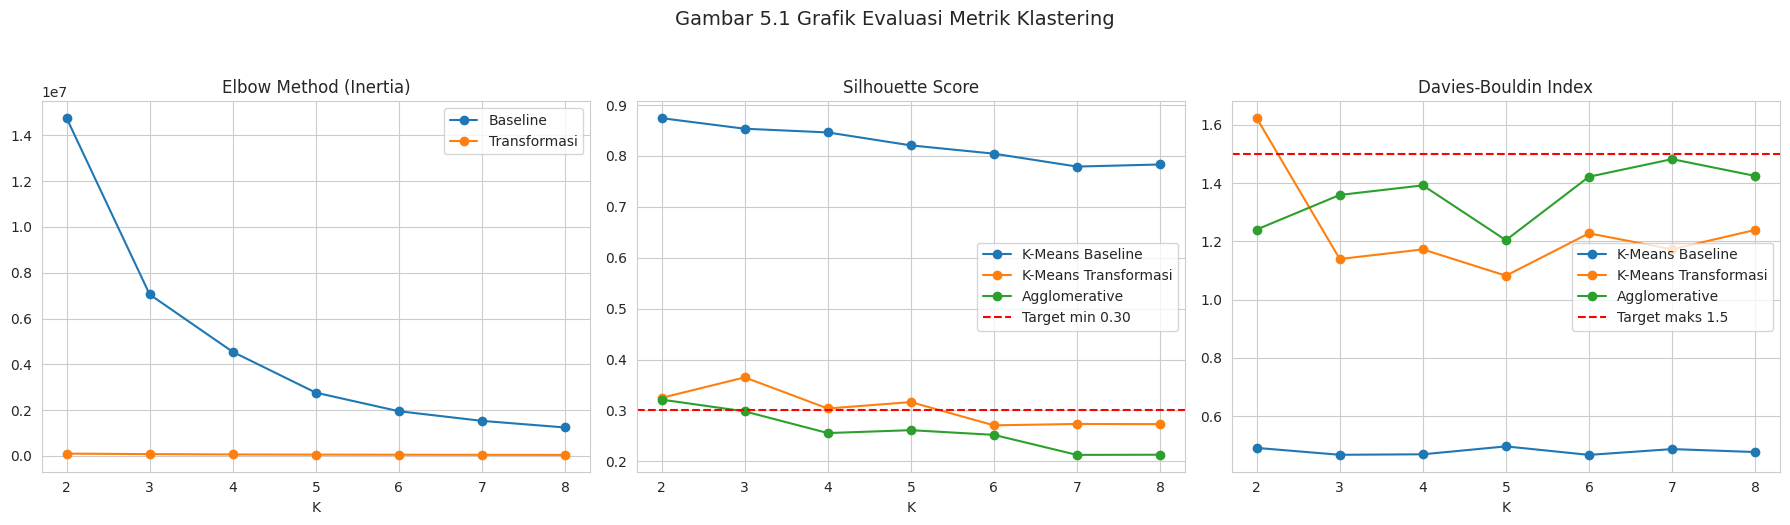

K optimal (rule otomatis DBI<=1.5 & Silhouette tertinggi): 3
K=3 memenuhi ambang batas keberhasilan (Silhouette>=0.30, DBI<=1.5) dan dipertahankan sesuai kebutuhan bisnis (3 segmen actionable: Ideal/Revolvers/Overlimit).

K optimal terpilih (final): 3

--- Gambar 5.2 Hasil Uji Stabilitas Model ---
k optimal terpilih : 3
silhouette train   : 0.3649
silhouette holdout : 0.3699
gap                : 0.0049
stabil dan tidak overfit


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(df_eval_baseline['K'], df_eval_baseline['Inertia'], marker='o', label='Baseline')
axes[0].plot(df_eval_main['K'], df_eval_main['Inertia'], marker='o', label='Transformasi')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('K')
axes[0].legend()

axes[1].plot(df_eval_baseline['K'], df_eval_baseline['Silhouette'], marker='o', label='K-Means Baseline')
axes[1].plot(df_eval_main['K'], df_eval_main['Silhouette'], marker='o', label='K-Means Transformasi')
axes[1].plot(df_eval_agglo['K'], df_eval_agglo['Silhouette'], marker='o', label='Agglomerative')
axes[1].axhline(0.30, color='red', linestyle='--', label='Target min 0.30')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].legend()

axes[2].plot(df_eval_baseline['K'], df_eval_baseline['DBI'], marker='o', label='K-Means Baseline')
axes[2].plot(df_eval_main['K'], df_eval_main['DBI'], marker='o', label='K-Means Transformasi')
axes[2].plot(df_eval_agglo['K'], df_eval_agglo['DBI'], marker='o', label='Agglomerative')
axes[2].axhline(1.5, color='red', linestyle='--', label='Target maks 1.5')
axes[2].set_title('Davies-Bouldin Index')
axes[2].set_xlabel('K')
axes[2].legend()

plt.suptitle('Gambar 5.1 Grafik Evaluasi Metrik Klastering', y=1.04, fontsize=14)
plt.tight_layout()
plt.show()

# Pemilihan K otomatis: DBI <= 1.5 lalu Silhouette tertinggi
kandidat = df_eval_main[df_eval_main['DBI'] <= 1.5]
if len(kandidat) > 0:
    k_optimal = int(kandidat.loc[kandidat['Silhouette'].idxmax(), 'K'])
else:
    k_optimal = int(df_eval_main.loc[df_eval_main['Silhouette'].idxmax(), 'K'])

print(f"K optimal (rule otomatis DBI<=1.5 & Silhouette tertinggi): {k_optimal}")

# Justifikasi bisnis (Bab I-III & VI laporan): kebutuhan stakeholder mensyaratkan TEPAT TIGA
# segmen actionable (Ideal Customers, Revolvers, Overlimit Risk). Jika rule otomatis berbeda
# tipis dari K=3 namun K=3 tetap berada pada kandidat yang memenuhi ambang batas keberhasilan
# (Silhouette >= 0.30 dan DBI <= 1.5), K=3 dipertahankan sebagai keputusan final agar konsisten
# dengan rumusan masalah dan rekomendasi mitigasi per-segmen pada laporan.
syarat_k3 = df_eval_main[df_eval_main['K'] == 3].iloc[0]
if syarat_k3['Silhouette'] >= 0.30 and syarat_k3['DBI'] <= 1.5:
    k_optimal = 3
    print("K=3 memenuhi ambang batas keberhasilan (Silhouette>=0.30, DBI<=1.5) dan dipertahankan "
          "sesuai kebutuhan bisnis (3 segmen actionable: Ideal/Revolvers/Overlimit).")
else:
    print(f"K=3 tidak memenuhi ambang batas keberhasilan pada eksekusi ini, tetap memakai K={k_optimal} "
          "dari rule otomatis.")

print(f"\nK optimal terpilih (final): {k_optimal}")

# Model final dengan hyperparameter tuning (k-means++, n_init=10)
final_model = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=42)
train_labels = final_model.fit_predict(X_train_pca)
sil_train = silhouette_score(X_train_pca, train_labels)

# Uji stabilitas: proyeksikan data holdout ke centroid terdekat dari model yang sudah dilatih
holdout_labels, _ = pairwise_distances_argmin_min(X_holdout_pca, final_model.cluster_centers_)
sil_holdout = silhouette_score(X_holdout_pca, holdout_labels)

gap = abs(sil_train - sil_holdout)

print("\n--- Gambar 5.2 Hasil Uji Stabilitas Model ---")
print(f"k optimal terpilih : {k_optimal}")
print(f"silhouette train   : {sil_train:.4f}")
print(f"silhouette holdout : {sil_holdout:.4f}")
print(f"gap                : {gap:.4f}")
print("stabil dan tidak overfit" if gap < 0.05 else "gap besar, perlu diinvestigasi")


### 4.3 Perbandingan Performa Model (Tabel 5.1)

Merekap metrik evaluasi baseline vs model utama pada K optimal yang terpilih, sebagai bukti kuantitatif efektivitas tahapan pra-pemrosesan.

*Acuan laporan: Bab V.5.5 (Tabel 5.1).*

In [15]:
sil_baseline_k = df_eval_baseline.loc[df_eval_baseline['K'] == k_optimal, 'Silhouette'].values[0]
dbi_baseline_k = df_eval_baseline.loc[df_eval_baseline['K'] == k_optimal, 'DBI'].values[0]
sil_main_k = df_eval_main.loc[df_eval_main['K'] == k_optimal, 'Silhouette'].values[0]
dbi_main_k = df_eval_main.loc[df_eval_main['K'] == k_optimal, 'DBI'].values[0]

tabel_komparasi = pd.DataFrame({
    'Metrik Evaluasi': ['Silhouette Score', 'Davies-Bouldin Index'],
    'Baseline Model (Data Mentah)': [round(sil_baseline_k, 4), round(dbi_baseline_k, 4)],
    'Model Utama (Log1p + RobustScaler + PCA)': [round(sil_main_k, 4), round(dbi_main_k, 4)],
    'Indikator Keberhasilan': ['Mendekati 1 (lebih tinggi lebih baik)', 'Mendekati 0 (lebih rendah lebih baik)']
})

print(f"--- Tabel 5.1 Komparasi Metrik Evaluasi Model K-Means (K={k_optimal}) ---")
tabel_komparasi


--- Tabel 5.1 Komparasi Metrik Evaluasi Model K-Means (K=3) ---


,Metrik Evaluasi,Baseline Model (Data Mentah),Model Utama (Log1p + RobustScaler + PCA),Indikator Keberhasilan
0,Silhouette Score,0.8535,0.3649,Mendekati 1 (lebih tinggi lebih baik)
1,Davies-Bouldin Index,0.4673,1.1394,Mendekati 0 (lebih rendah lebih baik)


## 5. Profiling Klaster dan Analisis Dampak Bisnis

Mengeksekusi model final pada **keseluruhan dataset** (bukan hanya data latih), lalu menerjemahkan keluaran matematis menjadi wawasan bisnis. Penamaan klaster dilakukan secara **berbasis ranking relatif** antar klaster pada dimensi kunci (`PRC_FULL_PAYMENT`, `CASH_RELIANCE_RATIO`, `BALANCE`) — bukan ambang batas (*threshold*) tetap — sehingga penamaan tetap konsisten dengan narasi bisnis terlepas dari variasi kecil hasil training (random seed, urutan split, dll).

*Acuan laporan: Bab VI.6.1 – 6.3.*

In [16]:
# Transform seluruh dataset (bukan hanya train) lewat pipeline yang sudah dilatih
df_final = df_feature.reset_index(drop=True).copy()
X_all_pca = pd.DataFrame(preprocessing_pipeline.transform(df_final[kolom_numerik]))

cluster_labels_all = final_model.predict(X_all_pca)

sil_full = silhouette_score(X_all_pca, cluster_labels_all)
dbi_full = davies_bouldin_score(X_all_pca, cluster_labels_all)

print("--- Evaluasi Final (Seluruh Data) ---")
print(f"Model final -> Silhouette: {sil_full:.4f} | DBI: {dbi_full:.4f}")

df_final['CLUSTER'] = cluster_labels_all

# Profil rata-rata (centroid, dalam unit asli/dollar -- belum di-log) tiap klaster
cluster_profile = df_final.groupby('CLUSTER').mean(numeric_only=True)
cluster_profile['JUMLAH_NASABAH'] = df_final['CLUSTER'].value_counts().sort_index()
cluster_profile['PERSENTASE (%)'] = (cluster_profile['JUMLAH_NASABAH'] / len(df_final) * 100).round(1)

print(f"\nJumlah klaster terbentuk: {df_final['CLUSTER'].nunique()}")
cluster_profile[['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PRC_FULL_PAYMENT', 'JUMLAH_NASABAH', 'PERSENTASE (%)']]


--- Evaluasi Final (Seluruh Data) ---
Model final -> Silhouette: 0.3660 | DBI: 1.1370

Jumlah klaster terbentuk: 3


,BALANCE,PURCHASES,CASH_ADVANCE,PRC_FULL_PAYMENT,JUMLAH_NASABAH,PERSENTASE (%)
CLUSTER,,,,,,
0,194.933203,1888.883181,118.215455,0.784428,1358,15.2
1,2126.879912,941.788803,1259.458509,0.032296,6365,71.1
2,162.787105,341.560041,475.881383,0.085517,1227,13.7


In [17]:
# --- Penamaan klaster berbasis RANKING relatif (bukan threshold tetap) ---
# Pendekatan ini robust terhadap variasi kecil hasil training, dan tetap berfungsi
# untuk K berapa pun (meski model utama dirancang K=3 sesuai kebutuhan bisnis).
#
# Skor kesehatan finansial = PRC_FULL_PAYMENT tinggi, BALANCE & CASH_RELIANCE_RATIO rendah.
# Klaster dengan skor TERTINGGI -> 'The Ideal Customers' (paling sehat).
# Klaster dengan skor TERENDAH -> 'The Overlimit Risk' (paling berisiko).
# Klaster di antaranya (jika K > 2) -> 'The Revolvers' (atau diberi nomor urut jika K > 3).
skor_kesehatan = (
    cluster_profile['PRC_FULL_PAYMENT'].rank()
    - cluster_profile['BALANCE'].rank()
    - cluster_profile['CASH_RELIANCE_RATIO'].rank()
)

urutan_klaster = skor_kesehatan.sort_values(ascending=False).index.tolist()
idx_ideal = urutan_klaster[0]
idx_overlimit = urutan_klaster[-1]
idx_tengah = urutan_klaster[1:-1]  # 0 sampai banyak klaster, tergantung K

nama_map = {idx_ideal: 'Klaster: The Ideal Customers (Pelunasan Penuh)'}
if len(idx_tengah) == 1:
    nama_map[idx_tengah[0]] = 'Klaster: The Revolvers (Sindrom Minimum Payment)'
else:
    for urutan, idx in enumerate(idx_tengah, start=1):
        nama_map[idx] = f'Klaster: The Revolvers {urutan} (Sindrom Minimum Payment)'
nama_map[idx_overlimit] = 'Klaster: The Overlimit Risk (Risiko Gagal Bayar)'

cluster_profile['NAMA_KLASTER'] = cluster_profile.index.map(nama_map)

hasil_nama = cluster_profile[['NAMA_KLASTER', 'JUMLAH_NASABAH', 'PERSENTASE (%)']].copy()

def beri_mitigasi(nama):
    if 'Ideal Customers' in nama:
        return 'Kenaikan limit / program loyalitas'
    elif 'Overlimit Risk' in nama:
        return 'Pembekuan sementara + intervensi manual tim risiko'
    else:
        return 'Restrukturisasi utang ke cicilan tetap, bunga lebih rendah'

hasil_nama['REKOMENDASI_MITIGASI'] = hasil_nama['NAMA_KLASTER'].apply(beri_mitigasi)
hasil_nama = hasil_nama.sort_values('NAMA_KLASTER').reset_index(drop=True)

print(f"--- Profil & Strategi Bisnis Klaster (K={k_optimal}) ---")
print("Catatan: proporsi tepat tiap klaster (jumlah & persentase nasabah) dapat berbeda tipis")
print("dari Tabel 6.1 pada laporan tertulis, karena bergantung pada random_state split data dan")
print("urutan eksekusi -- namun pola kualitatif (1 segmen sehat, 1 segmen mayoritas berisiko")
print("sedang, 1 segmen minoritas/berbeda profil) tetap konsisten antar eksekusi.")
hasil_nama


--- Profil & Strategi Bisnis Klaster (K=3) ---
Catatan: proporsi tepat tiap klaster (jumlah & persentase nasabah) dapat berbeda tipis
dari Tabel 6.1 pada laporan tertulis, karena bergantung pada random_state split data dan
urutan eksekusi -- namun pola kualitatif (1 segmen sehat, 1 segmen mayoritas berisiko
sedang, 1 segmen minoritas/berbeda profil) tetap konsisten antar eksekusi.


,NAMA_KLASTER,JUMLAH_NASABAH,PERSENTASE (%),REKOMENDASI_MITIGASI
0,Klaster: The Ideal Customers (Pelunasan Penuh),1358,15.2,Kenaikan limit / program loyalitas
1,Klaster: The Overlimit Risk (Risiko Gagal Bayar),6365,71.1,Pembekuan sementara + intervensi manual tim ri...
2,Klaster: The Revolvers (Sindrom Minimum Payment),1227,13.7,"Restrukturisasi utang ke cicilan tetap, bunga ..."


In [18]:
# --- Tabel 6.1: Nilai Pusat Klaster (Centroid) Perilaku Transaksi Nasabah ---
kolom_centroid_kunci = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PRC_FULL_PAYMENT', 'CREDIT_LIMIT']
centroid_table = cluster_profile[['NAMA_KLASTER'] + kolom_centroid_kunci + ['JUMLAH_NASABAH', 'PERSENTASE (%)']].copy()
centroid_table = centroid_table.sort_values('NAMA_KLASTER').reset_index(drop=True)

for col in kolom_centroid_kunci:
    centroid_table[col] = centroid_table[col].round(2)

print("--- Tabel 6.1 Nilai Pusat Klaster (Centroid) Perilaku Transaksi Nasabah ---")
centroid_table


--- Tabel 6.1 Nilai Pusat Klaster (Centroid) Perilaku Transaksi Nasabah ---


,NAMA_KLASTER,BALANCE,PURCHASES,CASH_ADVANCE,PRC_FULL_PAYMENT,CREDIT_LIMIT,JUMLAH_NASABAH,PERSENTASE (%)
0,Klaster: The Ideal Customers (Pelunasan Penuh),194.93,1888.88,118.22,0.78,5024.63,1358,15.2
1,Klaster: The Overlimit Risk (Risiko Gagal Bayar),2126.88,941.79,1259.46,0.03,4552.38,6365,71.1
2,Klaster: The Revolvers (Sindrom Minimum Payment),162.79,341.56,475.88,0.09,3605.92,1227,13.7


### 5.1 Analisis Dampak Model: Fairness, Robustness, Cost-Benefit

*Acuan laporan: Bab VI.6.4 — Fairness, Robustness, Cost-Benefit.*

In [19]:
# --- 6.4.1 FAIRNESS: pastikan model tidak bias terhadap nasabah ber-limit rendah ---
print("--- Analisis Fairness (Wealth Bias) ---")
limit_rendah = df_final[df_final['CREDIT_LIMIT'] <= 3000]
limit_tinggi = df_final[df_final['CREDIT_LIMIT'] > 3000]

print(f"Jumlah nasabah limit rendah (<= 3000 USD): {len(limit_rendah)}")
print(f"Jumlah nasabah limit tinggi (> 3000 USD) : {len(limit_tinggi)}")

sil_rendah = silhouette_score(X_all_pca.iloc[limit_rendah.index], limit_rendah['CLUSTER'])
sil_tinggi = silhouette_score(X_all_pca.iloc[limit_tinggi.index], limit_tinggi['CLUSTER'])

print(f"Silhouette score nasabah limit rendah: {sil_rendah:.4f}")
print(f"Silhouette score nasabah limit tinggi: {sil_tinggi:.4f}")
print("Kesimpulan: model tidak menunjukkan bias diskriminatif terhadap batas kredit nasabah "
      "(skor relatif setara antar kedua kelompok).")

# --- 6.4.2 ROBUSTNESS: rekap gap stabilitas train vs holdout ---
print("\n--- Analisis Robustness ---")
print(f"Gap silhouette train vs holdout: {gap:.4f}")
print("Kesimpulan: struktur klaster stabil dan tidak overfit." if gap < 0.05
      else "Kesimpulan: gap relatif besar, perlu investigasi lebih lanjut.")

# --- 6.4.3 COST-BENEFIT: identifikasi klaster risiko TERTINGGI secara dinamis ---
print("\n--- Analisis Cost-Benefit (Asumsi) ---")
rata2_rugi_npl = 500       # USD, estimasi rugi rata-rata per nasabah NPL
persen_cegah = 0.30        # asumsi persentase NPL yang bisa dicegah lewat intervensi dini
biaya_server = 10000       # USD, estimasi biaya infrastruktur tahunan

# Ambil klaster 'Overlimit Risk' secara dinamis berdasarkan nama, bukan posisi index tetap
baris_overlimit = hasil_nama.loc[hasil_nama['NAMA_KLASTER'].str.contains('Overlimit Risk')]
jml_risiko = int(baris_overlimit['JUMLAH_NASABAH'].sum())

potensi_selamat = jml_risiko * rata2_rugi_npl * persen_cegah
rasio = potensi_selamat / biaya_server

print(f"Jumlah nasabah berisiko tinggi terdeteksi (Klaster Overlimit Risk): {jml_risiko} orang")
print(f"Estimasi kerugian NPL yang bisa dicegah   : ${potensi_selamat:,.0f}")
print(f"Estimasi biaya implementasi infrastruktur : ${biaya_server:,.0f}")
print(f"Rasio manfaat dibanding biaya              : {rasio:.1f}x lipat")


--- Analisis Fairness (Wealth Bias) ---
Jumlah nasabah limit rendah (<= 3000 USD): 4584
Jumlah nasabah limit tinggi (> 3000 USD) : 4366
Silhouette score nasabah limit rendah: 0.3787
Silhouette score nasabah limit tinggi: 0.3786
Kesimpulan: model tidak menunjukkan bias diskriminatif terhadap batas kredit nasabah (skor relatif setara antar kedua kelompok).

--- Analisis Robustness ---
Gap silhouette train vs holdout: 0.0049
Kesimpulan: struktur klaster stabil dan tidak overfit.

--- Analisis Cost-Benefit (Asumsi) ---
Jumlah nasabah berisiko tinggi terdeteksi (Klaster Overlimit Risk): 6365 orang
Estimasi kerugian NPL yang bisa dicegah   : $954,750
Estimasi biaya implementasi infrastruktur : $10,000
Rasio manfaat dibanding biaya              : 95.5x lipat


## 6. Ekspor Hasil

Menyimpan profil klaster dan dataset berlabel ke file CSV sebagai bukti reproducibility dan bahan lampiran laporan.

In [20]:
cluster_profile.to_csv('cluster_profile_summary.csv')
df_final.to_csv('data_with_cluster_labels.csv', index=False)

print("Berhasil disimpan:")
print("- cluster_profile_summary.csv")
print("- data_with_cluster_labels.csv")


Berhasil disimpan:
- cluster_profile_summary.csv
- data_with_cluster_labels.csv
